In [2]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv(r"C:\PROJECT\Probforecast\data\raw\PJME_hourly.csv")
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').set_index('Datetime')

# 2. Handle duplicate timestamp telemetry artifacts
df = df.groupby(level=0).mean()

# 3. Feature Extraction Function
def create_time_features(data_frame):
    target_df = data_frame.copy()
    target_df['hour'] = target_df.index.hour
    target_df['dayofweek'] = target_df.index.dayofweek
    target_df['quarter'] = target_df.index.quarter
    target_df['month'] = target_df.index.month
    target_df['year'] = target_df.index.year
    target_df['dayofyear'] = target_df.index.dayofyear
    return target_df

df_features = create_time_features(df)

# 4. Chronological Splitting
cutoff_date = '2015-01-01'
train = df_features.loc[df_features.index < cutoff_date]
test = df_features.loc[df_features.index >= cutoff_date]

FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear']
TARGET = 'PJME_MW'

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"Setup Complete! Training shape: {X_train.shape}, Testing shape: {X_test.shape}")

Setup Complete! Training shape: (113925, 6), Testing shape: (31437, 6)


In [3]:
# Initialize the XGBoost Regressor
reg = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    learning_rate=0.01,
    max_depth=5,
    random_state=42
)

# Train the model using our split matrices
reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100  # Prints out validation loss metrics every 100 iterations
)

[0]	validation_0-rmse:6409.88419	validation_1-rmse:6481.53202
[100]	validation_0-rmse:4056.43864	validation_1-rmse:4406.78824
[200]	validation_0-rmse:3395.56907	validation_1-rmse:3913.22698
[300]	validation_0-rmse:3145.68521	validation_1-rmse:3745.12732
[400]	validation_0-rmse:2980.08371	validation_1-rmse:3723.11757
[428]	validation_0-rmse:2947.46462	validation_1-rmse:3725.18135


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [4]:
# Extract the final loss metrics from the model's history
final_train_rmse = reg.evals_result()['validation_0']['rmse'][-1]
final_test_rmse = reg.evals_result()['validation_1']['rmse'][-1]

print("--- Final Baseline Performance ---")
print(f"Training Root Mean Squared Error: {final_train_rmse:.2f} MW")
print(f"Testing Root Mean Squared Error:  {final_test_rmse:.2f} MW")

--- Final Baseline Performance ---
Training Root Mean Squared Error: 2947.46 MW
Testing Root Mean Squared Error:  3725.18 MW


In [5]:
# Create a copy of the dataframe to avoid altering the original
df_advanced = df.copy()

# 1. Generate Target Lags (1 day, 2 days, and 1 week back)
df_advanced['lag_24h'] = df_advanced['PJME_MW'].shift(24)
df_advanced['lag_48h'] = df_advanced['PJME_MW'].shift(48)
df_advanced['lag_168h'] = df_advanced['PJME_MW'].shift(168) # 24 * 7 days

# 2. Generate Rolling Statistics (24-hour moving average, shifted by 1 hour to prevent leakage)
# We shift by 1 because at the exact hour of prediction, we don't know the current hour's value yet!
df_advanced['rolling_mean_24h'] = df_advanced['PJME_MW'].shift(1).rolling(window=24).mean()

# Drop rows with NaN values created by the shifting process
df_advanced = df_advanced.dropna()

print("Advanced look-back features engineered successfully!")
print(f"New dataset shape: {df_advanced.shape}")

Advanced look-back features engineered successfully!
New dataset shape: (145194, 5)


In [6]:
# Re-extract the calendar features on our new dataframe structure
df_advanced['hour'] = df_advanced.index.hour
df_advanced['dayofweek'] = df_advanced.index.dayofweek
df_advanced['quarter'] = df_advanced.index.quarter
df_advanced['month'] = df_advanced.index.month
df_advanced['year'] = df_advanced.index.year
df_advanced['dayofyear'] = df_advanced.index.dayofyear

# Define the expanded feature set
ADVANCED_FEATURES = [
    'hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
    'lag_24h', 'lag_48h', 'lag_168h', 'rolling_mean_24h'
]
TARGET = 'PJME_MW'

# Re-apply the chronological split
train_adv = df_advanced.loc[df_advanced.index < cutoff_date]
test_adv = df_advanced.loc[df_advanced.index >= cutoff_date]

# Split into X and y matrices
X_train_adv = train_adv[ADVANCED_FEATURES]
y_train_adv = train_adv[TARGET]
X_test_adv = test_adv[ADVANCED_FEATURES]
y_test_adv = test_adv[TARGET]

print("Advanced matrices split perfectly!")
print(f"Training features shape: {X_train_adv.shape}")
print(f"Testing features shape:  {X_test_adv.shape}")

Advanced matrices split perfectly!
Training features shape: (113757, 10)
Testing features shape:  (31437, 10)


In [7]:
# Initialize the Advanced XGBoost Regressor
reg_adv = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    learning_rate=0.01,
    max_depth=5,
    random_state=42
)

# Train using the memory-infused matrices
reg_adv.fit(
    X_train_adv, y_train_adv,
    eval_set=[(X_train_adv, y_train_adv), (X_test_adv, y_test_adv)],
    verbose=100
)

[0]	validation_0-rmse:6400.37592	validation_1-rmse:6467.21317
[100]	validation_0-rmse:3147.08340	validation_1-rmse:3317.04633
[200]	validation_0-rmse:2220.47486	validation_1-rmse:2458.46698
[300]	validation_0-rmse:1941.65307	validation_1-rmse:2203.40981
[400]	validation_0-rmse:1830.21737	validation_1-rmse:2110.08958
[500]	validation_0-rmse:1774.01374	validation_1-rmse:2070.12531
[600]	validation_0-rmse:1730.83549	validation_1-rmse:2039.84140
[700]	validation_0-rmse:1695.32300	validation_1-rmse:2014.81355
[800]	validation_0-rmse:1664.01983	validation_1-rmse:1991.54505
[900]	validation_0-rmse:1635.65431	validation_1-rmse:1969.98764
[999]	validation_0-rmse:1609.70697	validation_1-rmse:1949.95575


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [8]:
final_train_rmse_adv = reg_adv.evals_result()['validation_0']['rmse'][-1]
final_test_rmse_adv = reg_adv.evals_result()['validation_1']['rmse'][-1]

print("--- Advanced Model Performance ---")
print(f"Advanced Training RMSE: {final_train_rmse_adv:.2f} MW")
print(f"Advanced Testing RMSE:  {final_test_rmse_adv:.2f} MW")

--- Advanced Model Performance ---
Advanced Training RMSE: 1609.71 MW
Advanced Testing RMSE:  1949.96 MW


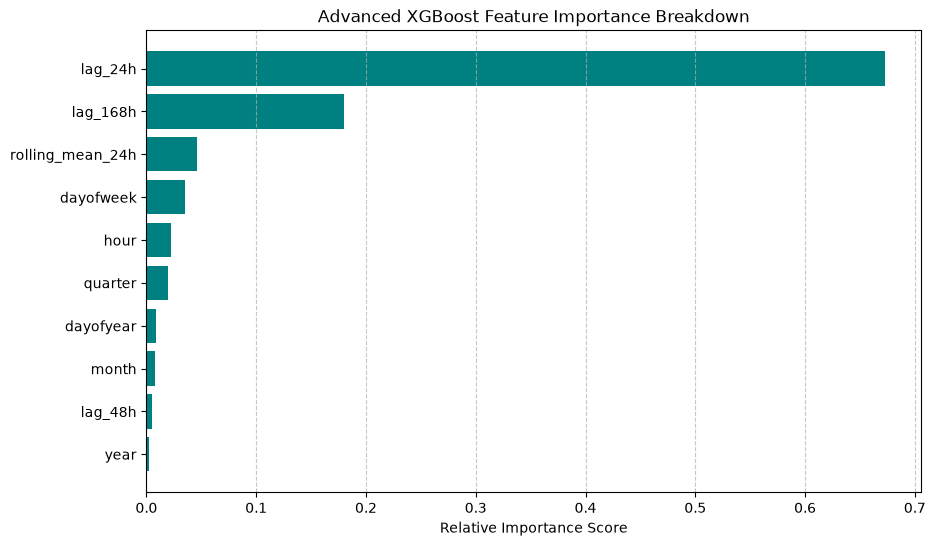

In [9]:
# Map features to their importance weights and sort them
importance_df = pd.DataFrame({
    'Feature': ADVANCED_FEATURES,
    'Importance': reg_adv.feature_importances_
}).sort_values(by='Importance', ascending=True)

# Plot a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.xlabel('Relative Importance Score')
plt.title('Advanced XGBoost Feature Importance Breakdown')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [10]:
import lightgbm as lgb

# Initialize LightGBM Regressor
model_lgb = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    random_state=42
)

# Train the challenger model using early stopping via callbacks
model_lgb.fit(
    X_train_adv, y_train_adv,
    eval_set=[(X_test_adv, y_test_adv)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# Predict and compute test error
preds_lgb = model_lgb.predict(X_test_adv)
from sklearn.metrics import root_mean_squared_error
test_rmse_lgb = root_mean_squared_error(y_test_adv, preds_lgb)

print("--- LightGBM Challenger Performance ---")
print(f"LightGBM Testing RMSE: {test_rmse_lgb:.2f} MW")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004008 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1338
[LightGBM] [Info] Number of data points in the train set: 113757, number of used features: 10
[LightGBM] [Info] Start training from score 32289.035549
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [12]:
# 1. Train the Upper Bound Model (90th Percentile)
print("Training Upper Bound Model (90th percentile)...")
reg_upper = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    objective='reg:quantileerror',  # Fixed name
    quantile_alpha=0.90,
    random_state=42
)
reg_upper.fit(X_train_adv, y_train_adv)

# 2. Train the Lower Bound Model (10th Percentile)
print("Training Lower Bound Model (10th percentile)...")
reg_lower = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    objective='reg:quantileerror',  # Fixed name
    quantile_alpha=0.10,
    random_state=42
)
reg_lower.fit(X_train_adv, y_train_adv)

print("Probabilistic boundary models trained successfully!")

Training Upper Bound Model (90th percentile)...
Training Lower Bound Model (10th percentile)...
Probabilistic boundary models trained successfully!


In [13]:
# Generate boundary predictions on the test set
test_adv = test_adv.copy()
test_adv['lower_bound'] = reg_lower.predict(X_test_adv)
test_adv['upper_bound'] = reg_upper.predict(X_test_adv)

# Calculate if the true value fell within our predicted window
test_adv['in_bounds'] = (test_adv[TARGET] >= test_adv['lower_bound']) & (test_adv[TARGET] <= test_adv['upper_bound'])
coverage_rate = test_adv['in_bounds'].mean() * 100

print("--- Probabilistic Evaluation ---")
print(f"Empirical Coverage Rate: {coverage_rate:.2f}%")

--- Probabilistic Evaluation ---
Empirical Coverage Rate: 72.39%
